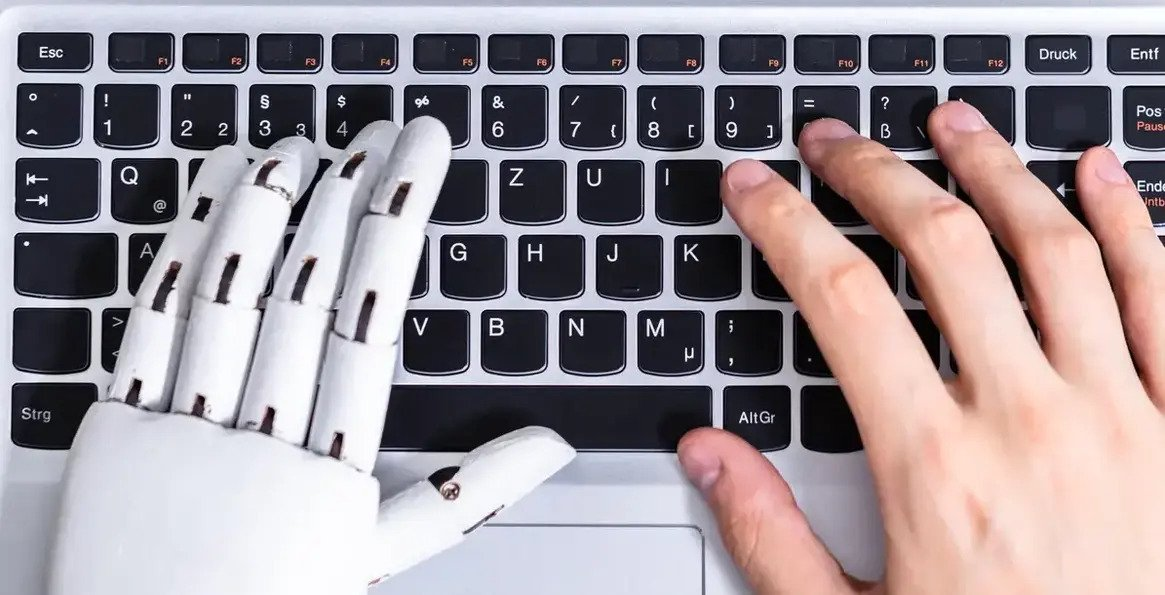

*[Image source](https://www.google.com/url?sa=i&url=https%3A%2F%2Fwww.theguardian.com%2Fcommentisfree%2F2022%2Fnov%2F28%2Fai-students-essays-cheat-teachers-plagiarism-tech&psig=AOvVaw295hyxagJ8A8ZcDKCVVp-O&ust=1696978092284000&source=images&cd=vfe&opi=89978449&ved=0CBMQjhxqFwoTCLCE_JSG6oEDFQAAAAAdAAAAABAJ)*

# Linking Writing Processes to Writing Quality

This work is modified from the notebooks https://www.kaggle.com/code/hengzheng/link-writing-simple-lgbm-baseline and its fork https://www.kaggle.com/code/abhranta/lgbm-finetuning-with-optuna. Please upvote these notebooks!

# Set Global Configuration Options

In [ ]:
class CONFIG:
    '''
    > General Options
    '''
    # global seed
    seed = 42
    # the number of samples to use for testing purposes
    # if None, we use the full dataset
    samples_testing = None #None
    # max rows to display for pandas dataframes
    display_max_rows = 100
    # name of the response variate we are trying to predict
    response_variate = 'score'
    
    '''
    > Preprocessing Options
    '''
    # number of folds to split the data for CV
    num_folds = 10
    
    '''
    > Modelling Options
    '''
    # whether to use optuna tuning or not
    # if False, then we load in pretuned weights for the LGBM models
    use_optuna_tuning = False
    # size of the test set for optuna tuning
    # if use_optuna_tuning=True
    test_size_optuna = 0.2
    # number of estimators to use for the boosting model
    num_estimators = 5000
    # number of trials to use for optuna tuning
    # if use_optuna_tuning=True
    num_trials_optuna = 80
    # number of trials to use for early stopping
    num_trials_early_stopping = 40
    
    '''
    > Post-Modelling Options
    '''
    # number of most important features to display
    # for the feature importances plot
    num_features_to_display = 50

# Import Utility Script & Libraries

In [ ]:
import warnings

import os
import gc
import re
import random
from collections import Counter

import numpy as np
import pandas as pd
from scipy.stats import skew, kurtosis
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.autonotebook import tqdm

from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import KFold, StratifiedKFold, GroupKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics import mean_squared_error

import lightgbm as lgb
import optuna

In [ ]:
tqdm.pandas()

sns.set_style("whitegrid")

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', CONFIG.display_max_rows)
warnings.simplefilter('ignore')

random.seed(CONFIG.seed)

# Load Data

In [ ]:
INPUT_DIR = '/kaggle/input/linking-writing-processes-to-writing-quality'

train_logs = pd.read_csv(f'{INPUT_DIR}/train_logs.csv')
train_scores = pd.read_csv(f'{INPUT_DIR}/train_scores.csv')
test_logs = pd.read_csv(f'{INPUT_DIR}/test_logs.csv')

In [ ]:
df_train = train_logs.merge(train_scores, on="id", suffixes=(None, None))

## Subsample Data (If Specified)

In [ ]:
if CONFIG.samples_testing is not None:
    ids = list(train_logs["id"].unique())
    sample_ids = random.sample(ids, CONFIG.samples_testing)
    train_logs = train_logs[train_logs["id"].isin(sample_ids)]

In [ ]:
train_logs.head()

# Feature Engineering

In [ ]:
class Preprocessor:
    
    def __init__(self, seed):
        self.seed = seed
        
        self.activities = ['Input', 'Remove/Cut', 'Nonproduction', 'Replace', 'Paste']
        self.events = ['q', 'Space', 'Backspace', 'Shift', 'ArrowRight', 'Leftclick', 'ArrowLeft', '.', ',', 
              'ArrowDown', 'ArrowUp', 'Enter', 'CapsLock', "'", 'Delete', 'Unidentified']
        self.text_changes = ['q', ' ', 'NoChange', '.', ',', '\n', "'", '"', '-', '?', ';', '=', '/', '\\', ':']
        self.punctuations = ['"', '.', ',', "'", '-', ';', ':', '?', '!', '<', '>', '/',
                        '@', '#', '$', '%', '^', '&', '*', '(', ')', '_', '+']
        self.gaps = [1, 2, 3, 5, 10, 20, 50]
#         self.gaps = [1, 2]
    
    def activity_counts(self, df):
        tmp_df = df.groupby('id').agg({'activity': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['activity'].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.activities:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'activity_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret


    def event_counts(self, df, colname):
        tmp_df = df.groupby('id').agg({colname: list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df[colname].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.events:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'{colname}_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret


    def text_change_counts(self, df):
        tmp_df = df.groupby('id').agg({'text_change': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['text_change'].values):
            items = list(Counter(li).items())
            di = dict()
            for k in self.text_changes:
                di[k] = 0
            for item in items:
                k, v = item[0], item[1]
                if k in di:
                    di[k] = v
            ret.append(di)
        ret = pd.DataFrame(ret)
        cols = [f'text_change_{i}_count' for i in range(len(ret.columns))]
        ret.columns = cols
        return ret

    def match_punctuations(self, df):
        tmp_df = df.groupby('id').agg({'down_event': list}).reset_index()
        ret = list()
        for li in tqdm(tmp_df['down_event'].values):
            cnt = 0
            items = list(Counter(li).items())
            for item in items:
                k, v = item[0], item[1]
                if k in self.punctuations:
                    cnt += v
            ret.append(cnt)
        ret = pd.DataFrame({'punct_cnt': ret})
        return ret


    def get_input_words(self, df):
        tmp_df = df[(~df['text_change'].str.contains('=>'))&(df['text_change'] != 'NoChange')].reset_index(drop=True)
        tmp_df = tmp_df.groupby('id').agg({'text_change': list}).reset_index()
        tmp_df['text_change'] = tmp_df['text_change'].apply(lambda x: ''.join(x))
        tmp_df['text_change'] = tmp_df['text_change'].apply(lambda x: re.findall(r'q+', x))
        tmp_df['input_word_count'] = tmp_df['text_change'].apply(len)
        tmp_df['input_word_length_mean'] = tmp_df['text_change'].apply(lambda x: np.mean([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df['input_word_length_max'] = tmp_df['text_change'].apply(lambda x: np.max([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df['input_word_length_std'] = tmp_df['text_change'].apply(lambda x: np.std([len(i) for i in x] if len(x) > 0 else 0))
        tmp_df.drop(['text_change'], axis=1, inplace=True)
        return tmp_df
    
    def make_feats(self, df):
        
        print("Starting to engineer features")
        
        # initialize features dataframe
        feats = pd.DataFrame({'id': df['id'].unique().tolist()})
        
        # get shifted features
        # time shift
        print("Engineering time data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'up_time_shift{gap}'] = df.groupby('id')['up_time'].shift(gap)
            df[f'action_time_gap{gap}'] = df['down_time'] - df[f'up_time_shift{gap}']
        df.drop(columns=[f'up_time_shift{gap}' for gap in self.gaps], inplace=True)

        # cursor position shift
        print("Engineering cursor position data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'cursor_position_shift{gap}'] = df.groupby('id')['cursor_position'].shift(gap)
            df[f'cursor_position_change{gap}'] = df['cursor_position'] - df[f'cursor_position_shift{gap}']
            df[f'cursor_position_abs_change{gap}'] = np.abs(df[f'cursor_position_change{gap}'])
        df.drop(columns=[f'cursor_position_shift{gap}' for gap in self.gaps], inplace=True)

        # word count shift
        print("Engineering word count data")
        for gap in self.gaps:
            print(f"> for gap {gap}")
            df[f'word_count_shift{gap}'] = df.groupby('id')['word_count'].shift(gap)
            df[f'word_count_change{gap}'] = df['word_count'] - df[f'word_count_shift{gap}']
            df[f'word_count_abs_change{gap}'] = np.abs(df[f'word_count_change{gap}'])
        df.drop(columns=[f'word_count_shift{gap}' for gap in self.gaps], inplace=True)
        
        # get aggregate statistical features
        print("Engineering statistical summaries for features")
        # [(feature name, [ stat summaries to add ])]
        feats_stat = [
            ('event_id', ['max']),
            ('up_time', ['max']),
            ('action_time', ['sum', 'max', 'mean', 'std']),
            ('activity', ['nunique']),
            ('down_event', ['nunique']),
            ('up_event', ['nunique']),
            ('text_change', ['nunique']),
            ('cursor_position', ['nunique', 'max', 'mean']),
            ('word_count', ['nunique', 'max', 'mean'])]
        for gap in self.gaps:
            feats_stat.extend([
                (f'action_time_gap{gap}', ['max', 'min', 'mean', 'std', 'sum', skew, kurtosis]),
                (f'cursor_position_change{gap}', ['max', 'mean', 'std', 'sum', skew, kurtosis]),
                (f'word_count_change{gap}', ['max', 'mean', 'std', 'sum', skew, kurtosis])
            ])
        
        pbar = tqdm(feats_stat)
        for item in pbar:
            colname, methods = item[0], item[1]
            for method in methods:
                pbar.set_postfix()
                if isinstance(method, str):
                    method_name = method
                else:
                    method_name = method.__name__
                    
                pbar.set_postfix(column=colname, method=method_name)
                tmp_df = df.groupby(['id']).agg({colname: method}).reset_index().rename(columns={colname: f'{colname}_{method_name}'})
                feats = feats.merge(tmp_df, on='id', how='left')

        # counts
        print("Engineering activity counts data")
        tmp_df = self.activity_counts(df)
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering event counts data")
        tmp_df = self.event_counts(df, 'down_event')
        feats = pd.concat([feats, tmp_df], axis=1)
        tmp_df = self.event_counts(df, 'up_event')
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering text change counts data")
        tmp_df = self.text_change_counts(df)
        feats = pd.concat([feats, tmp_df], axis=1)
        
        print("Engineering punctuation counts data")
        tmp_df = self.match_punctuations(df)
        feats = pd.concat([feats, tmp_df], axis=1)

        # input words
        print("Engineering input words data")
        tmp_df = self.get_input_words(df)
        feats = pd.merge(feats, tmp_df, on='id', how='left')

        # compare feats
        print("Engineering ratios data")
        feats['word_time_ratio'] = feats['word_count_max'] / feats['up_time_max']
        feats['word_event_ratio'] = feats['word_count_max'] / feats['event_id_max']
        feats['event_time_ratio'] = feats['event_id_max']  / feats['up_time_max']
        feats['idle_time_ratio'] = feats['action_time_gap1_sum'] / feats['up_time_max']
        
        print("Done!")
        return feats

In [ ]:
preprocessor = Preprocessor(seed=CONFIG.seed)

print("-"*25)
print("Engineering features for training data")
print("-"*25)
train_feats = preprocessor.make_feats(train_logs)

print()
print("-"*25)
print("Engineering features for test data")
print("-"*25)
test_feats = preprocessor.make_feats(test_logs)

In [ ]:
train_feats = train_feats.merge(train_scores, on='id', how='left')

In [ ]:
print(f"Shape of training data: {train_feats.shape}")
print(f"Shape of test data: {test_feats.shape}")

In [ ]:
train_feats.head()

In [ ]:
test_feats.head()

# Split Train Data Into Folds For Cross-Validation

In [ ]:
kfold = KFold(n_splits=CONFIG.num_folds, shuffle=True, random_state=CONFIG.seed)
for fold, (_, val_idx) in enumerate(kfold.split(train_feats)):
    train_feats.loc[val_idx, "fold"] = fold

# Optimizing Hyperparameters with Optuna

In [ ]:
X = train_feats.drop(columns=['id', 'fold', CONFIG.response_variate])
Y = train_feats[CONFIG.response_variate]

In [ ]:
# TODO: change this to CV OOF using kfold cross-validation instead of train test split
# can also change the categorical of parameters into "suggest_float"
def objective(trial,data=X,target=Y):
    
    train_x, test_x, train_y, test_y = train_test_split(data, target, test_size=CONFIG.test_size_optuna,random_state=42)
    param = {
        'metric': 'rmse', 
        'random_state': CONFIG.seed,
        'n_estimators': CONFIG.num_estimators,
        'reg_alpha': trial.suggest_loguniform('reg_alpha', 1e-3, 10.0),
        'reg_lambda': trial.suggest_loguniform('reg_lambda', 1e-3, 10.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1),
        'subsample': trial.suggest_float('subsample', 0.5, 1),
        'learning_rate': trial.suggest_float('learning_rate', 1e-4, 0.1, log=True),
        'num_leaves' : trial.suggest_int('num_leaves', 8, 64),
        'min_child_samples': trial.suggest_int('min_child_samples', 1, 100),
    }
    model = lgb.LGBMRegressor(**param)  
    
    model.fit(train_x,train_y,eval_set=[(test_x,test_y)],early_stopping_rounds=100,verbose=False)
    
    preds = model.predict(test_x)
    
    rmse = mean_squared_error(test_y, preds,squared=False)
    
    return rmse


In [ ]:
if CONFIG.use_optuna_tuning:
    study = optuna.create_study(direction='minimize', study_name='Optimize boosting hyperparameters')
    study.optimize(objective, n_trials=CONFIG.num_trials_optuna)

In [ ]:
if CONFIG.use_optuna_tuning:
    print('Best trial:', study.best_trial.params)

# Train OOF LGBM Models

In [ ]:
feature_names = list(
    filter(lambda x: x not in [CONFIG.response_variate, 'id', 'fold'], train_feats.columns))

if not CONFIG.use_optuna_tuning:
    best_params = {'reg_alpha': 0.30650185736659397, 
                   'reg_lambda': 0.08235806165155644, 
                   'colsample_bytree': 0.5547938642836329, 
                   'subsample': 0.782269098248984, 
                   'learning_rate': 0.02572229832068531, 
                   'num_leaves': 14, 
                   'min_child_samples': 43}
else:
    best_params = study.best_params

lgbm_params = {
    'metric': 'rmse', 
    'random_state': CONFIG.seed,
    'n_estimators': CONFIG.num_estimators,
    **best_params
}

# [fold]: model
models_dict = {}

for fold in range(CONFIG.num_folds):
    
    print(f"Training for FOLD {fold}")
    
    X_train = train_feats[train_feats["fold"] != fold][feature_names]
    Y_train = train_feats[train_feats["fold"] != fold][CONFIG.response_variate]

    X_val = train_feats[train_feats["fold"] == fold][feature_names]
    Y_val = train_feats[train_feats["fold"] == fold][CONFIG.response_variate]
    
    model = lgb.LGBMRegressor(**lgbm_params)

    model.fit(X_train,
              Y_train,
              eval_names=['train', 'valid'],
              eval_set=[(X_train, Y_train), (X_val, Y_val)],
              verbose=-1,
              eval_metric='rmse',
              early_stopping_rounds=CONFIG.num_trials_early_stopping)
    
    models_dict[fold] = model

# Mean Feature Importances OF LGBM Models

In [ ]:
feature_importances_values = np.asarray([model.feature_importances_ for model in models_dict.values()]).mean(axis=0)
feature_importance_df = pd.DataFrame({'name': feature_names, 'importance': feature_importances_values})

feature_importance_df = feature_importance_df.sort_values('importance', ascending=False).head(CONFIG.num_features_to_display)

In [ ]:
plt.figure(figsize=(15, 6))

ax = sns.barplot(data=feature_importance_df, x='name', y='importance')
ax.set_title(f"Mean feature importances")
ax.set_xticks(ax.get_xticks(), ax.get_xticklabels(), rotation=90)

plt.show()

# Evaluation of OOF Preds on Training Set (CV)

In [ ]:
for fold in range(CONFIG.num_folds):
    print(f"Predicting the train set with FOLD {fold}")
    X_train = train_feats[train_feats["fold"] != fold][feature_names]
    Y_train = train_feats[train_feats["fold"] != fold][CONFIG.response_variate]

    X_val = train_feats[train_feats["fold"] == fold][feature_names]
    Y_val = train_feats[train_feats["fold"] == fold][CONFIG.response_variate]
    
    lgb_model = models_dict[fold]
    pred_val = lgb_model.predict(X_val, 
                                 num_iteration=lgb_model.best_iteration_)
    train_feats.loc[X_val.index, f"pred_{CONFIG.response_variate}"] = pred_val

In [ ]:
rmse = mean_squared_error(train_feats[CONFIG.response_variate], 
                          np.clip(train_feats[f"pred_{CONFIG.response_variate}"], a_min=0.5, a_max=6.0), 
                          squared=False)
print('CV RMSE:', rmse)

# Predicting The Test Set

We use the mean of all the predictions for all the fold models

In [ ]:
for fold in range(CONFIG.num_folds):
    print(f"Predicting the test set with FOLD {fold}")
    X_test = test_feats[feature_names]
    
    lgb_model = models_dict[fold]
    pred = lgb_model.predict(X_test, 
                            num_iteration=lgb_model.best_iteration_)
    test_feats[f"pred_{CONFIG.response_variate}_fold{fold}"] = pred
    
test_feats[CONFIG.response_variate] = test_feats[[f"pred_{CONFIG.response_variate}_fold{fold}"\
                                               for fold in range(CONFIG.num_folds)]].mean(axis=1)
test_feats[CONFIG.response_variate] = np.clip(test_feats[CONFIG.response_variate], a_min=0.5, a_max=6.0)

# Submission

In [ ]:
submission = test_feats[["id", CONFIG.response_variate]]
submission

In [ ]:
submission.to_csv('submission.csv', index=False)

# Thanks for reading!

# Please leave an upvote if this was helpful!